# Comparison: ADD_TO_TRAIN × discard_criteria

For each combination of dataset filter (`discard_criteria`) and train injection (`ADD_TO_TRAIN`), runs the selected model(s) on all tasks and produces a histogram via `user_study_plot_hist`.

**Dataset configs (4):**
1. `all` — no filtering
2. `no_distractor` — discard distractor
3. `no_camera` — discard camera_not_working
4. `good_only` — discard all known bad criteria

**ADD_TO_TRAIN configs (3):**
- `[]` — no injection
- `[0,1,2]` — one trajectory per label moved from test to train
- `[0,1,2,0,1,2]` — two trajectories per label

Histograms are saved under `auto_fig_generator/add_to_train_comparison/`.

Using cache found in /home/steve/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /home/steve/.cache/torch/hub/facebookresearch_dinov2_main
Nominal / no_inject / dinov2 small attn: 100%|██████████| 29/29 [00:36<00:00,  1.27s/it]


i:  35


Visual distractor / no_inject / dinov2 small attn: 100%|██████████| 20/20 [00:31<00:00,  1.58s/it]


i:  23


Limited observability / no_inject / dinov2 small attn: 100%|██████████| 21/21 [00:23<00:00,  1.12s/it]


i:  21


Acquisition/setup failure / no_inject / dinov2 small attn: 100%|██████████| 7/7 [00:07<00:00,  1.01s/it]

i:  7
grouped_stats keys:  dict_keys(['Nominal', 'Visual distractor', 'Limited observability', 'Acquisition/setup failure'])


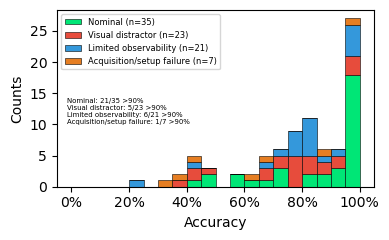

Nominal / inject_1each / dinov2 small attn: 100%|██████████| 29/29 [00:35<00:00,  1.21s/it]


i:  35


Visual distractor / inject_1each / dinov2 small attn: 100%|██████████| 20/20 [00:30<00:00,  1.53s/it]


i:  23


Limited observability / inject_1each / dinov2 small attn: 100%|██████████| 21/21 [00:22<00:00,  1.06s/it]


i:  21


Acquisition/setup failure / inject_1each / dinov2 small attn: 100%|██████████| 7/7 [00:06<00:00,  1.03it/s]

i:  7
grouped_stats keys:  dict_keys(['Nominal', 'Visual distractor', 'Limited observability', 'Acquisition/setup failure'])


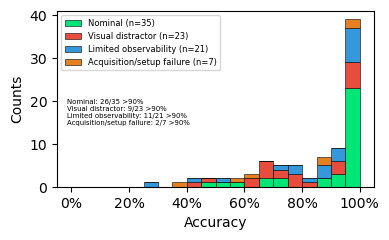

Nominal / inject_2each / dinov2 small attn: 100%|██████████| 29/29 [00:33<00:00,  1.17s/it]


i:  35


Visual distractor / inject_2each / dinov2 small attn: 100%|██████████| 20/20 [00:30<00:00,  1.55s/it]


i:  23


Limited observability / inject_2each / dinov2 small attn: 100%|██████████| 21/21 [00:22<00:00,  1.08s/it]


i:  21


Acquisition/setup failure / inject_2each / dinov2 small attn: 100%|██████████| 7/7 [00:06<00:00,  1.05it/s]

i:  7
grouped_stats keys:  dict_keys(['Nominal', 'Visual distractor', 'Limited observability', 'Acquisition/setup failure'])


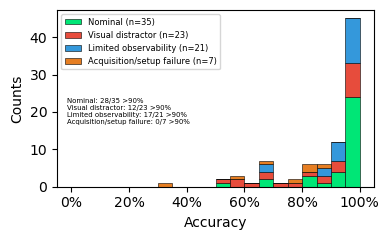

Nominal / no_inject / dinov2 small concat: 100%|██████████| 29/29 [00:37<00:00,  1.31s/it]


i:  35


Visual distractor / no_inject / dinov2 small concat: 100%|██████████| 20/20 [00:33<00:00,  1.66s/it]


i:  23


Limited observability / no_inject / dinov2 small concat: 100%|██████████| 21/21 [00:24<00:00,  1.16s/it]


i:  21


Acquisition/setup failure / no_inject / dinov2 small concat: 100%|██████████| 7/7 [00:07<00:00,  1.04s/it]

i:  7
grouped_stats keys:  dict_keys(['Nominal', 'Visual distractor', 'Limited observability', 'Acquisition/setup failure'])


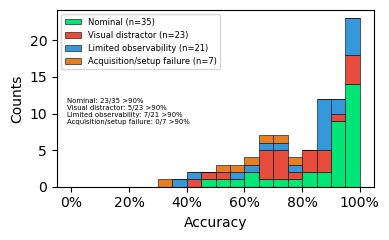

Nominal / inject_1each / dinov2 small concat: 100%|██████████| 29/29 [00:37<00:00,  1.29s/it]


i:  35


Visual distractor / inject_1each / dinov2 small concat: 100%|██████████| 20/20 [00:32<00:00,  1.65s/it]


i:  23


Limited observability / inject_1each / dinov2 small concat: 100%|██████████| 21/21 [00:23<00:00,  1.13s/it]


i:  21


Acquisition/setup failure / inject_1each / dinov2 small concat: 100%|██████████| 7/7 [00:07<00:00,  1.02s/it]


i:  7
grouped_stats keys:  dict_keys(['Nominal', 'Visual distractor', 'Limited observability', 'Acquisition/setup failure'])


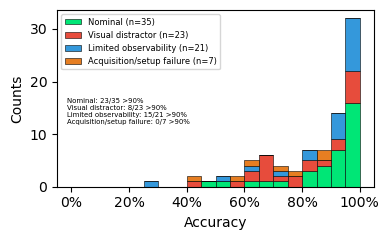

Nominal / inject_2each / dinov2 small concat: 100%|██████████| 29/29 [00:35<00:00,  1.23s/it]


i:  35


Visual distractor / inject_2each / dinov2 small concat: 100%|██████████| 20/20 [00:31<00:00,  1.58s/it]


i:  23


Limited observability / inject_2each / dinov2 small concat: 100%|██████████| 21/21 [00:22<00:00,  1.09s/it]


i:  21


Acquisition/setup failure / inject_2each / dinov2 small concat: 100%|██████████| 7/7 [00:06<00:00,  1.04it/s]

i:  7
grouped_stats keys:  dict_keys(['Nominal', 'Visual distractor', 'Limited observability', 'Acquisition/setup failure'])


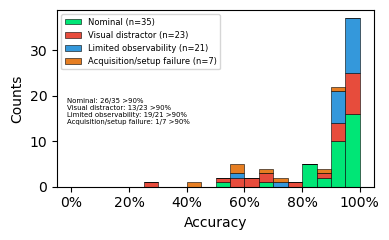

Overall accuracy on train data: nan%
Overall accuracy on train data: nan%
Overall accuracy on train data: nan%


/tmp/ipykernel_236404/3405923384.py:125: RuntimeWarning: Mean of empty slice.
  print(f"Overall accuracy on train data: {round(np.array(viz[i[1]]['test']).mean(), 2)}%")
/home/steve/micromamba/envs/gesturenlu2/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
import numpy as np
from tqdm import tqdm
from nocode_robot_programming.state_decision.utils import (
    kill_other_ipykernels, user_study_tasks_only, user_study_plot_hist_grouped, set_seed
)
from nocode_robot_programming.state_decision.state_decider import (
    StateDeciderBase, DINOFeaturePresence, DINOFeaturePresenceConcat,
    DINOFeaturePresenceAttnGated, DINOWithMIL, StateDeciderSIFT, AEGP
)
from nocode_robot_programming.state_decision_dataset_prepare.dataset_auto import TrajectoryDatasetEvaluationViewBuilder
from nocode_robot_programming.state_decision.plots.benchmark_plot import visualize_accuracies, visualize_accuracies_3d
from nocode_robot_programming.jupyter_plot import jupyter_plot as ipt
# kill_other_ipykernels(force=True)
set_seed()

CRITERIA_CSV = "trajectory_criteria.csv"
TASKS = ['peg_pick', 'probe', 'wrap']
ANOMALY_DATASET = False
OUT_DIR = "add_to_train_comparison"
percentile_keep = None # 0.1

DECIDERS = [
    DINOFeaturePresenceAttnGated(dino_variant="dinov2_vits14", percentile_keep=percentile_keep, attn_mode="hard", head_reduce="mean", attn_keep=0.4),
    DINOFeaturePresenceConcat(dino_variant="dinov2_vits14", percentile_keep=percentile_keep),
    # DINOFeaturePresence(dino_variant="dinov2_vits14", percentile_keep=percentile_keep),
    # DINOFeaturePresence(dino_variant="facebook/dinov3-vits16-pretrain-lvd1689m", percentile_keep=percentile_keep), # DINOv3
    # DINOWithMIL(dino_variant= "dinov2_vits14", att_hidden = 128, dropout_p = 0.1, lr = 1e-4, weight_decay = 1e-3, epochs = 1000, percentile_keep=percentile_keep),
    # StateDeciderSIFT(method = "SIFT", percentile_keep=percentile_keep), # suggesting the background problem
    # AEGP(binary=False, pix=64),
]

DATASET_CONFIGS = [
    # {"name": "heatmap_plot",  "use_criteria": frozenset(["", "distractor", "target_features_not_visible_or_too_small", "hand_in_scene", "very_bad_train_data"])},
    {"name": "Nominal",          "use_criteria": frozenset([""])},
    {"name": "Visual distractor",  "use_criteria": frozenset(["distractor"])},
    {"name": "Limited observability",      "use_criteria": frozenset(["target_features_not_visible_or_too_small", "hand_in_scene", "very_bad_train_data"])},
    {"name": "Acquisition/setup failure",        "use_criteria": frozenset(["camera_not_working", "teaching_multiple_things_at_once"])},
]

ADD_TO_TRAIN_CONFIGS = [
    ([], "no_inject"),
    ([0, 1, 2], "inject_1each"),
    ([0, 1, 2, 0, 1, 2], "inject_2each"),
]

# Which dataset config feeds visualize_accuracies_3d heatmaps
VISUALIZE_DC_NAME = "heatmap_plot"

BRACKETS = []

# Keyed by decider.short_name; holds per-injection-level train/test/names lists
all_viz = {}

for decider in DECIDERS:
    viz = {add_name: {"train": [], "test": [], "names": []} for _, add_name in ADD_TO_TRAIN_CONFIGS}

    for add_to_train, add_name in ADD_TO_TRAIN_CONFIGS:
        grouped_stats = {}
        for dc in DATASET_CONFIGS:
            dataset_builder = TrajectoryDatasetEvaluationViewBuilder(
                criteria_csv=CRITERIA_CSV,
                sync_criteria_csv=False,
                print_criteria_report=False,
                use_criteria=dc["use_criteria"],
            )
            stats = {}
            desc = f"{dc['name']} / {add_name} / {decider.short_name}"
            ds_count = 0
            for name in tqdm(user_study_tasks_only(dataset_builder, TASKS), desc=desc):
                for d_train, d_test, d_text in dataset_builder.load_eval_from_task(
                        name, anomaly=ANOMALY_DATASET, add_to_train=add_to_train):
                    ds_count += 1
                    try:
                        decider.train(d_train.X, d_train.y_int, d_train.y_cls)
                    except AssertionError:
                        continue
                    y_pred_test = decider.predict_many(d_test.X)
                    test_acc = (np.array(d_test.y_names) == np.array(y_pred_test)).mean()
                    if dc["name"] != VISUALIZE_DC_NAME:
                        if d_text in stats.keys():
                            stats[d_text+f"{np.random.randint(0, 1000)}"] = test_acc
                        else:
                            stats[d_text] = test_acc
                    if dc["name"] == VISUALIZE_DC_NAME:
                        y_pred_train = decider.predict_many(d_train.X)
                        train_acc = (np.array(d_train.y_names) == np.array(y_pred_train)).mean()
                        viz[add_name]["train"].append(train_acc * 100)
                        viz[add_name]["test"].append(test_acc * 100)
                        viz[add_name]["names"].append(d_text.split(",")[0])
            print("Total decision states (DS): ", ds_count)
            grouped_stats[dc["name"]] = stats

        user_study_plot_hist_grouped(
            grouped_stats,
            BRACKETS,
            f"{add_name}_{decider.short_name}.pdf",
            print_howmany_over_90=True,
            bins=21,
            folder=OUT_DIR,
        )

    all_viz[decider.short_name] = viz

# Single heatmap for all     "deciders — cells show no-inj / 1-traj / 2-traj accuracy
add_names = [add_name for _, add_name in ADD_TO_TRAIN_CONFIGS]
names = next(iter(all_viz.values()))[ADD_TO_TRAIN_CONFIGS[0][1]]["names"]
if names:
    train_3d = [[[all_viz[dec][add_name]["train"][j] for add_name in add_names]
                 for j in range(len(names))]
                for dec in all_viz]
    test_3d  = [[[all_viz[dec][add_name]["test"][j]  for add_name in add_names]
                 for j in range(len(names))]
                for dec in all_viz]
    visualize_accuracies_3d(
        train_3d, test_3d,
        list(all_viz.keys()),
        names,
        out_dir=OUT_DIR,
        jupyter_plot=False,
    )
ipt.show()


for i in ADD_TO_TRAIN_CONFIGS:
    print(f"Overall accuracy on train data: {round(np.array(viz[i[1]]['test']).mean(), 2)}%")